In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load the dataset using a relative path
df_q2 = pd.read_csv('../data/q2_customers.csv')

# Scale all features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_q2)

print("Data loaded and scaled. Shape:", df_q2.shape)

Data loaded and scaled. Shape: (500, 6)


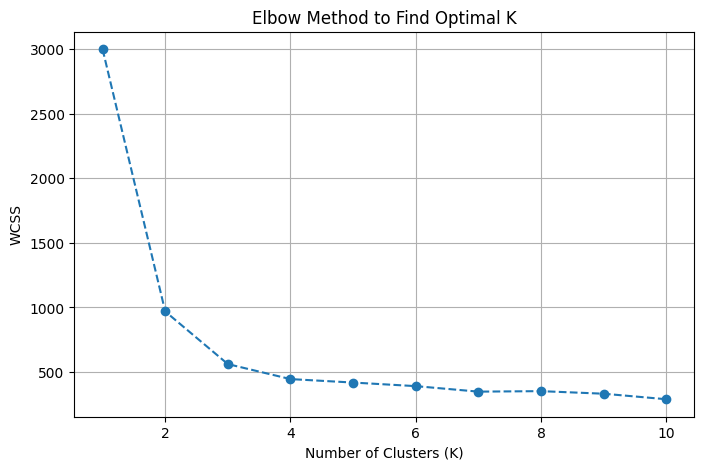

In [6]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [7]:
# Fit K-Means with K=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df_q2['cluster'] = kmeans.fit_predict(df_scaled)

# Print cluster centroids as a readable dataframe
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                         columns=df_q2.columns[:-1])
print("Cluster Centroids:")
display(centroids)

Cluster Centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [8]:
# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Feature Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df_q2.columns[:-1])
print("\nFeature Loadings:")
display(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


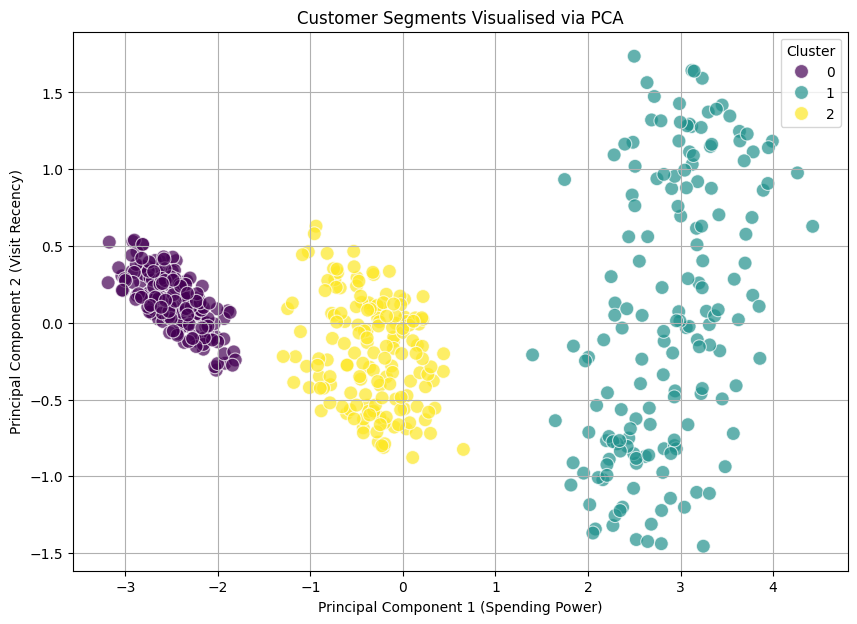

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df_q2['cluster'], 
                palette='viridis', s=100, alpha=0.7)

plt.title('Customer Segments Visualised via PCA')
plt.xlabel('Principal Component 1 (Spending Power)')
plt.ylabel('Principal Component 2 (Visit Recency)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()